# 📊 Notebook 1 : Exploration des Données du Challenge MPEG-G Microbiome

**Objectifs** :
1. Charger et comprendre tous les fichiers CSV
2. Analyser la distribution des classes (SampleType)
3. Explorer les métadonnées patient
4. Identifier les patterns, déséquilibres, valeurs manquantes
5. Vérifier l'accès aux fichiers .mgb

---

In [1]:
# Imports nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports réussis")

✅ Imports réussis


## 1️⃣ Chargement des Données

In [2]:
# Chemins vers les données
DATA_PATH = Path('../data/raw')

# Charger tous les fichiers CSV
train_df = pd.read_csv(DATA_PATH / 'Train.csv')
test_df = pd.read_csv(DATA_PATH / 'Test.csv')
subjects_df = pd.read_csv(DATA_PATH / 'Train_Subjects.csv')

print(f"📁 Train : {train_df.shape}")
print(f"📁 Test : {test_df.shape}")
print(f"📁 Subjects : {subjects_df.shape}")

📁 Train : (2901, 4)
📁 Test : (1068, 1)
📁 Subjects : (66, 17)


In [3]:
# Aperçu Train.csv
print("\n=== TRAIN.CSV ===")
display(train_df.head(10))
print("\nInfo :")
print(train_df.info())


=== TRAIN.CSV ===


,filename,SampleType,SubjectID,SampleID
0,ID_LETPJN.mgb,Stool,Subject_BCUNIB,Sample_AFTIWE
1,ID_NTDGIW.mgb,Stool,Subject_UDAXIH,Sample_JQJVNK
2,ID_ZISBMF.mgb,Nasal,Subject_VRKADI,Sample_YJWGWW
3,ID_MDCVXU.mgb,Nasal,Subject_HIFZWD,Sample_VKEHZP
4,ID_SWAMNY.mgb,Stool,Subject_VGLNCV,Sample_NTDTEQ
5,ID_QRIANS.mgb,Stool,Subject_CBVHYJ,Sample_MBZSNE
6,ID_KSEFAE.mgb,Nasal,Subject_UDAXIH,Sample_UZKJRT
7,ID_XHAOGA.mgb,Stool,Subject_UDAXIH,Sample_YDYNHF
8,ID_SRAOCX.mgb,Nasal,Subject_ASRHSH,Sample_JKXLXK
9,ID_BJCMPA.mgb,Nasal,Subject_FXORWN,Sample_WDPPXS



Info :
<class 'pandas.DataFrame'>
RangeIndex: 2901 entries, 0 to 2900
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    2901 non-null   str  
 1   SampleType  2901 non-null   str  
 2   SubjectID   2901 non-null   str  
 3   SampleID    2901 non-null   str  
dtypes: str(4)
memory usage: 90.8 KB
None


In [4]:
# Aperçu Test.csv
print("\n=== TEST.CSV ===")
display(test_df.head(10))
print(f"\nNombre de samples à prédire : {len(test_df)}")


=== TEST.CSV ===


,filename
0,ID_YBNOYC.mgb
1,ID_HPVLUO.mgb
2,ID_DQGGYD.mgb
3,ID_XZBUJB.mgb
4,ID_KRPYRQ.mgb
5,ID_WJYUAL.mgb
6,ID_CNYSMN.mgb
7,ID_RCYKMF.mgb
8,ID_PDGUOD.mgb
9,ID_RRPSJN.mgb



Nombre de samples à prédire : 1068


In [ ]:
# Aperçu Train_Subjects.csv
print("\n=== TRAIN_SUBJECTS.CSV ===")
display(subjects_df.head())
print("\nInfo :")
print(subjects_df.info())


=== TRAIN_SUBJECTS.CSV ===


,SubjectID,FPG_Mean,FPG_class,IRIS,SSPG,FPG,SSPG.Date,Class,Gender,Ethnicity,Adj.age,BMI,OGTT,OGTT_Class,Longitudinal.HbA1C.Group,A1C_Class,Family
0,Subject_UDAXIH,1.274432,Diabetes,IS,91.5,131.75,8/7/14,Diabetic,M,C,59.48,21.47,2.245,Diabetes,6. Variable Diabetic-PreDM (n = 8),6.VDP,NaN
1,Subject_NHOSIZ,0.915833,Normal,Unknown,NaN,NaN,NaN,Prediabetic,M,C,61.17,27.06,1.005,Normal,3. PreDM-to-Normal (n = 10),3.PN,NaN
2,Subject_AYZFWN,0.952000,Normal,Unknown,NaN,NaN,NaN,Prediabetic,F,A,56.22,30.61,NaN,NaN,1. Normal (n = 51),1.Normal,NaN
3,Subject_KIEGYK,1.160000,Prediabetes,Unknown,NaN,NaN,NaN,Prediabetic,M,C,49.18,23.22,NaN,NaN,1. Normal (n = 51),1.Normal,NaN
4,Subject_CBVHYJ,0.880000,Normal,Unknown,NaN,NaN,NaN,Control,F,C,46.04,25.26,0.930,Normal,1. Normal (n = 51),1.Normal,NaN



Info :
<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SubjectID                 66 non-null     str    
 1   FPG_Mean                  66 non-null     float64
 2   FPG_class                 66 non-null     str    
 3   IRIS                      66 non-null     str    
 4   SSPG                      44 non-null     float64
 5   FPG                       44 non-null     float64
 6   SSPG.Date                 42 non-null     str    
 7   Class                     66 non-null     str    
 8   Gender                    66 non-null     str    
 9   Ethnicity                 66 non-null     str    
 10  Adj.age                   66 non-null     float64
 11  BMI                       66 non-null     float64
 12  OGTT                      56 non-null     float64
 13  OGTT_Class                61 non-null     str    
 14  Longitudinal.Hb

## 2️⃣ Analyse de la Variable Cible : SampleType

In [7]:
# Distribution des classes
print("=== DISTRIBUTION DES CLASSES ===")
class_counts = train_df['SampleType'].value_counts()
class_percentages = train_df['SampleType'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages.round(2)
})

print(class_summary)
print(f"\nTotal samples : {len(train_df)}")

# Vérifier le déséquilibre
max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class
print(f"\n⚠️ Ratio déséquilibre : {imbalance_ratio:.2f}")
if imbalance_ratio > 2:
    print("→ Déséquilibre significatif détecté ! Prévoir class_weight ou SMOTE")
else:
    print("→ Classes relativement équilibrées")

=== DISTRIBUTION DES CLASSES ===
            Count  Percentage
SampleType                   
Stool         811       27.96
Skin          787       27.13
Nasal         710       24.47
Mouth         593       20.44

Total samples : 2901

⚠️ Ratio déséquilibre : 1.37
→ Classes relativement équilibrées


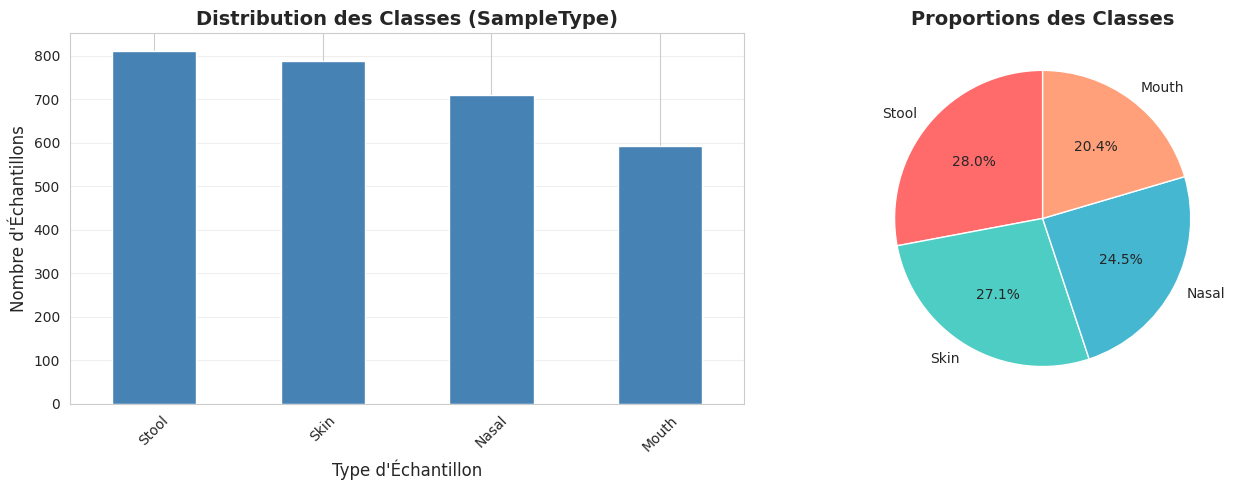

✅ Figure sauvegardée : results/figures/01_class_distribution.png


In [9]:
# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution des Classes (SampleType)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Type d\'Échantillon', fontsize=12)
axes[0].set_ylabel('Nombre d\'Échantillons', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
axes[1].set_title('Proportions des Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Figure sauvegardée : results/figures/01_class_distribution.png")

## 3️⃣ Analyse des Sujets (Patients)

In [10]:
# Combien de sujets uniques dans train ?
print("=== ANALYSE DES SUJETS ===")
n_subjects_train = train_df['SubjectID'].nunique()
n_samples_train = len(train_df)

print(f"Nombre de sujets (patients) uniques : {n_subjects_train}")
print(f"Nombre total d'échantillons : {n_samples_train}")
print(f"Moyenne échantillons par sujet : {n_samples_train / n_subjects_train:.2f}")

# Distribution échantillons par sujet
samples_per_subject = train_df.groupby('SubjectID').size().sort_values(ascending=False)
print(f"\nMax échantillons d'un sujet : {samples_per_subject.max()}")
print(f"Min échantillons d'un sujet : {samples_per_subject.min()}")
print(f"\nTop 10 sujets avec le plus d'échantillons :")
print(samples_per_subject.head(10))

=== ANALYSE DES SUJETS ===
Nombre de sujets (patients) uniques : 66
Nombre total d'échantillons : 2901
Moyenne échantillons par sujet : 43.95

Max échantillons d'un sujet : 441
Min échantillons d'un sujet : 1

Top 10 sujets avec le plus d'échantillons :
SubjectID
Subject_UDAXIH    441
Subject_HBHSCC    159
Subject_CHDMIO    138
Subject_ASRHSH    111
Subject_VGLNCV    105
Subject_PZNGDD    100
Subject_FSIBDT     93
Subject_MMTOQI     85
Subject_HIFZWD     80
Subject_FNAFXK     80
dtype: int64


In [11]:
# Distribution des types d'échantillons par sujet
subject_sample_types = train_df.groupby('SubjectID')['SampleType'].apply(lambda x: x.unique().tolist())
subject_n_types = subject_sample_types.apply(len)

print("\n=== DIVERSITÉ DES SITES PAR SUJET ===")
print(subject_n_types.value_counts().sort_index())
print(f"\nSujets avec échantillons de plusieurs sites : {(subject_n_types > 1).sum()}")
print(f"Sujets avec échantillons d'un seul site : {(subject_n_types == 1).sum()}")


=== DIVERSITÉ DES SITES PAR SUJET ===
SampleType
1     1
3     8
4    57
Name: count, dtype: int64

Sujets avec échantillons de plusieurs sites : 65
Sujets avec échantillons d'un seul site : 1


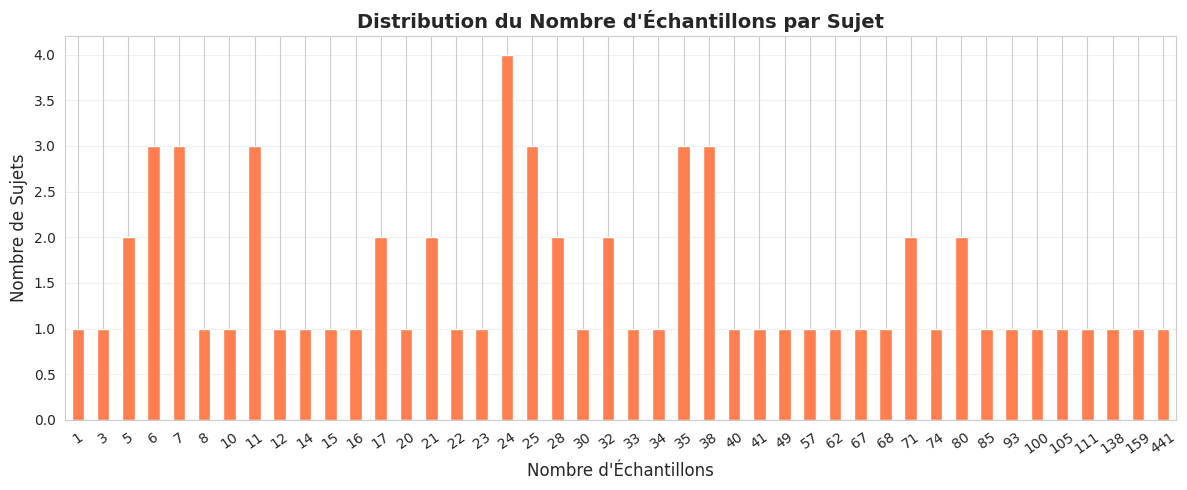

In [17]:
# Visualisation : Nombre d'échantillons par sujet
plt.figure(figsize=(12, 5))
samples_per_subject.value_counts().sort_index().plot(kind='bar', color='coral', rot=35)
plt.title('Distribution du Nombre d\'Échantillons par Sujet', fontsize=14, fontweight='bold')
plt.xlabel('Nombre d\'Échantillons', fontsize=12)
plt.ylabel('Nombre de Sujets', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/01_samples_per_subject.png', dpi=300, bbox_inches='tight')
plt.show()

## 4️⃣ Analyse des Métadonnées Patient (Train_Subjects)

In [18]:
# Statistiques descriptives des variables numériques
print("=== STATISTIQUES DES MÉTADONNÉES PATIENT ===")
numeric_cols = subjects_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nVariables numériques disponibles : {numeric_cols}")

display(subjects_df[numeric_cols].describe().T)

=== STATISTIQUES DES MÉTADONNÉES PATIENT ===

Variables numériques disponibles : ['FPG_Mean', 'SSPG', 'FPG', 'Adj.age', 'BMI', 'OGTT']


,count,mean,std,min,25%,50%,75%,max
FPG_Mean,66.0,0.940581,0.117552,0.756,0.870000,0.902557,1.017500,1.274432
SSPG,44.0,149.815000,68.402027,40.000,90.375000,156.935000,220.000000,274.000000
FPG,44.0,99.937500,11.397818,78.000,94.750000,97.500000,101.937500,138.000000
Adj.age,66.0,54.976212,10.315599,29.180,49.772500,55.300000,61.747500,75.230000
BMI,66.0,27.895000,4.334436,19.100,25.040000,27.195000,30.092500,40.830000
OGTT,56.0,1.371667,0.455184,0.640,1.089167,1.250000,1.533125,3.087500


In [21]:
# Valeurs manquantes
print("\n=== VALEURS MANQUANTES ===")
missing = subjects_df.isna().sum()
missing_pct = (missing / len(subjects_df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct.round(2)
}).sort_values('Missing_Count', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0])

if missing_df['Missing_Count'].sum() > 0:
    print("\n⚠️ Stratégies à prévoir : imputation (médiane/mode) ou suppression de colonnes")
else:
    print("\n✅ Aucune valeur manquante !")


=== VALEURS MANQUANTES ===
            Missing_Count  Missing_Percentage
Family                 60               90.91
SSPG.Date              24               36.36
FPG                    22               33.33
SSPG                   22               33.33
OGTT                   10               15.15
OGTT_Class              5                7.58

⚠️ Stratégies à prévoir : imputation (médiane/mode) ou suppression de colonnes


In [22]:
# Variables catégorielles
print("\n=== VARIABLES CATÉGORIELLES ===")
categorical_cols = subjects_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('SubjectID')  # Exclure l'ID

for col in categorical_cols[:5]:  # Afficher les 5 premières
    print(f"\n{col} :")
    print(subjects_df[col].value_counts())


=== VARIABLES CATÉGORIELLES ===

FPG_class :
FPG_class
Normal         48
Prediabetes    17
Diabetes        1
Name: count, dtype: int64

IRIS :
IRIS
IR         23
Unknown    22
IS         21
Name: count, dtype: int64

SSPG.Date :
SSPG.Date
8/4/15      2
8/7/14      1
2/3/15      1
6/25/13     1
10/8/13     1
10/14/13    1
6/30/15     1
11/12/13    1
9/1/17      1
3/31/15     1
12/11/13    1
4/15/15     1
8/8/14      1
8/6/14      1
7/21/14     1
8/20/14     1
10/28/14    1
5/13/15     1
11/18/14    1
11/25/14    1
11/20/15    1
12/9/14     1
9/17/15     1
6/23/15     1
5/11/11     1
11/16/15    1
8/27/17     1
5/6/16      1
7/7/17      1
7/12/17     1
5/1/17      1
5/30/12     1
6/1/12      1
7/17/12     1
9/11/12     1
12/18/12    1
7/8/13      1
4/23/13     1
5/7/13      1
10/15/13    1
10/21/13    1
Name: count, dtype: int64

Class :
Class
Prediabetic    43
Control        11
Crossover      10
Diabetic        2
Name: count, dtype: int64

Gender :
Gender
M    33
F    33
Name: count, d

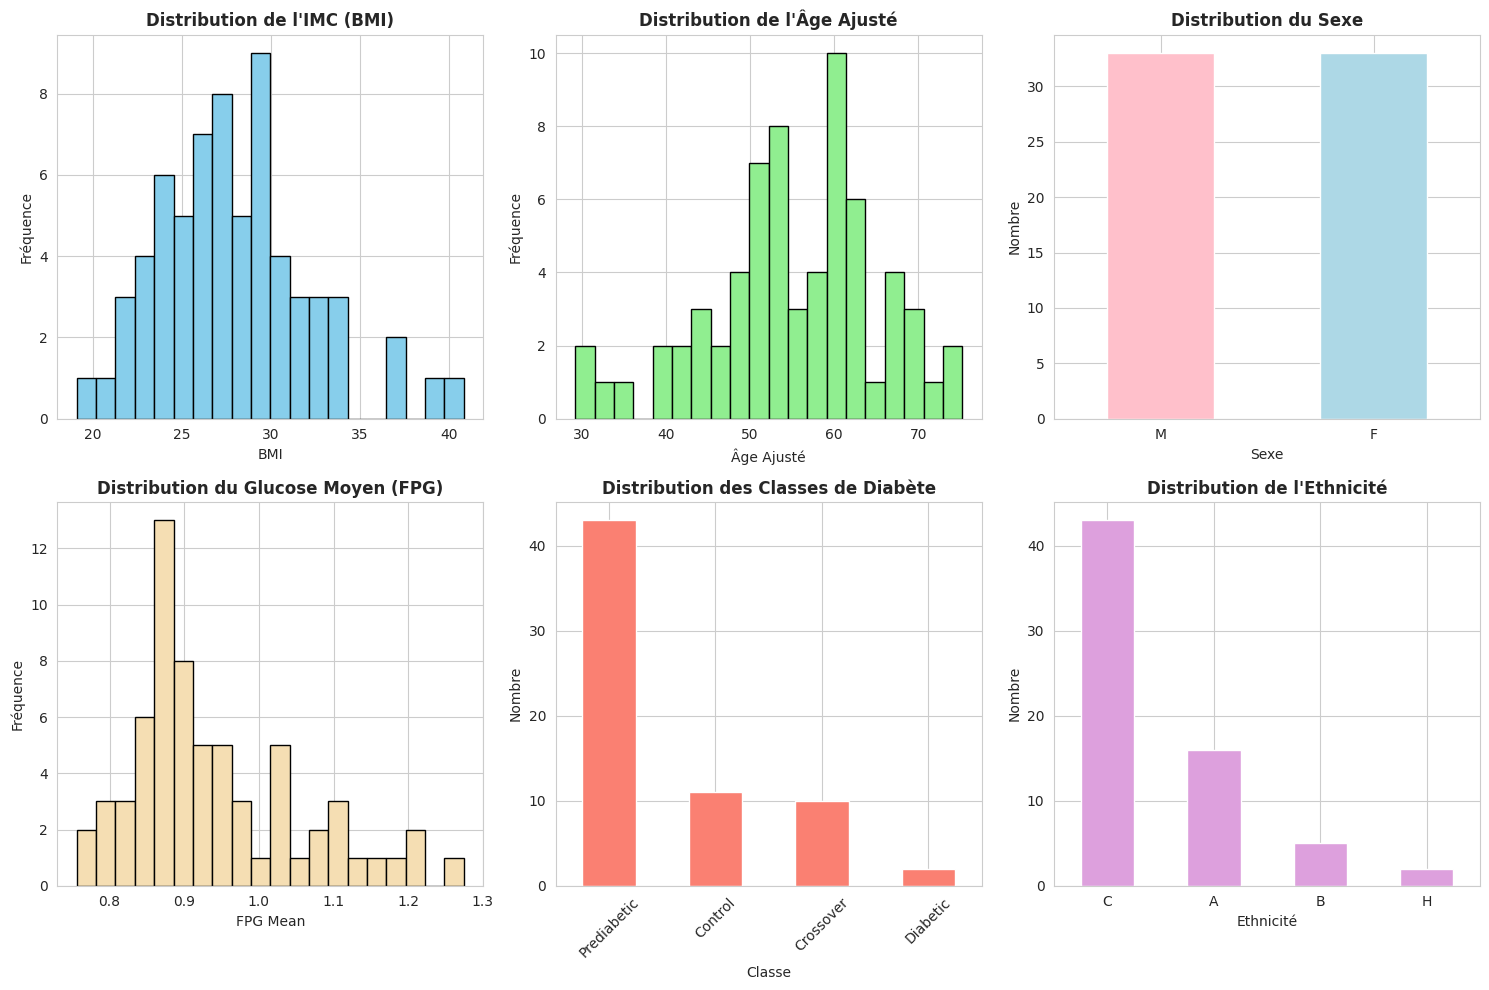

In [23]:
# Visualisation des features clés
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# BMI
subjects_df['BMI'].hist(bins=20, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution de l\'IMC (BMI)', fontweight='bold')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('Fréquence')

# Age
subjects_df['Adj.age'].hist(bins=20, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution de l\'Âge Ajusté', fontweight='bold')
axes[0, 1].set_xlabel('Âge Ajusté')
axes[0, 1].set_ylabel('Fréquence')

# Gender
subjects_df['Gender'].value_counts().plot(kind='bar', ax=axes[0, 2], color=['pink', 'lightblue'])
axes[0, 2].set_title('Distribution du Sexe', fontweight='bold')
axes[0, 2].set_xlabel('Sexe')
axes[0, 2].set_ylabel('Nombre')
axes[0, 2].tick_params(axis='x', rotation=0)

# FPG_Mean
subjects_df['FPG_Mean'].hist(bins=20, ax=axes[1, 0], color='wheat', edgecolor='black')
axes[1, 0].set_title('Distribution du Glucose Moyen (FPG)', fontweight='bold')
axes[1, 0].set_xlabel('FPG Mean')
axes[1, 0].set_ylabel('Fréquence')

# Class (diabète)
subjects_df['Class'].value_counts().plot(kind='bar', ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Distribution des Classes de Diabète', fontweight='bold')
axes[1, 1].set_xlabel('Classe')
axes[1, 1].set_ylabel('Nombre')
axes[1, 1].tick_params(axis='x', rotation=45)

# Ethnicity
subjects_df['Ethnicity'].value_counts().plot(kind='bar', ax=axes[1, 2], color='plum')
axes[1, 2].set_title('Distribution de l\'Ethnicité', fontweight='bold')
axes[1, 2].set_xlabel('Ethnicité')
axes[1, 2].set_ylabel('Nombre')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/01_subject_metadata.png', dpi=300, bbox_inches='tight')
plt.show()

## 5️⃣ Merge Train avec Métadonnées Patient

In [24]:
# Joindre train_df et subjects_df
train_full = train_df.merge(subjects_df, on='SubjectID', how='left')
print(f"Train après merge : {train_full.shape}")
print(f"\nNombre de lignes avec métadonnées manquantes : {train_full.isnull().any(axis=1).sum()}")

display(train_full.head())

Train après merge : (2901, 20)

Nombre de lignes avec métadonnées manquantes : 2802


,filename,SampleType,SubjectID,SampleID,FPG_Mean,FPG_class,IRIS,SSPG,FPG,SSPG.Date,Class,Gender,Ethnicity,Adj.age,BMI,OGTT,OGTT_Class,Longitudinal.HbA1C.Group,A1C_Class,Family
0,ID_LETPJN.mgb,Stool,Subject_BCUNIB,Sample_AFTIWE,1.063333,Prediabetes,Unknown,NaN,NaN,NaN,Prediabetic,F,C,41.65,40.83,1.870000,Prediabetes,5. Prediabetic (PreDM) (n = 14),5.P,NaN
1,ID_NTDGIW.mgb,Stool,Subject_UDAXIH,Sample_JQJVNK,1.274432,Diabetes,IS,91.5,131.75,8/7/14,Diabetic,M,C,59.48,21.47,2.245000,Diabetes,6. Variable Diabetic-PreDM (n = 8),6.VDP,NaN
2,ID_ZISBMF.mgb,Nasal,Subject_VRKADI,Sample_YJWGWW,0.899545,Normal,IR,220.0,95.00,12/18/12,Prediabetic,M,C,62.88,32.94,1.891667,Prediabetes,4. Variable Normal-PreDM (n = 21),4.VNP,NaN
3,ID_MDCVXU.mgb,Nasal,Subject_HIFZWD,Sample_VKEHZP,0.800000,Normal,IR,235.0,100.00,5/30/12,Prediabetic,M,C,60.71,34.15,1.510000,Prediabetes,3. PreDM-to-Normal (n = 10),3.PN,NaN
4,ID_SWAMNY.mgb,Stool,Subject_VGLNCV,Sample_NTDTEQ,0.882667,Normal,IR,162.0,99.00,10/21/13,Control,F,C,58.65,31.24,1.028333,Normal,1. Normal (n = 51),1.Normal,NaN


In [25]:
# Sauvegarder le train fusionné
train_full.to_csv('../data/processed/train_with_metadata.csv', index=False)
print("✅ Sauvegardé : data/processed/train_with_metadata.csv")

✅ Sauvegardé : data/processed/train_with_metadata.csv
